In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.stats as st
import src.eye_movement_preprocessing as emp

In [3]:
def get_uniform_cdf(first_trial_start, last_trial_start, first_trial_end, last_trial_end, scale):
    #first_trial_start = min(preprocessed_trial_data['startTime_to_startTime_to_flashOnTime_aligned'].values)
    #last_trial_start = max(preprocessed_trial_data['startTime_to_startTime_to_flashOnTime_aligned'].values)
    #first_trial_end = min(preprocessed_trial_data['endTime_to_startTime_to_flashOnTime_aligned'].values)
    #last_trial_end = max(preprocessed_trial_data['endTime_to_startTime_to_flashOnTime_aligned'].values)
    uniform_dist = []
    for val in scale:
        if val < first_trial_start:
            uniform_dist.append(0.00001)
        elif val >= first_trial_start and val < last_trial_start:
            uniform_dist.append((val - first_trial_start) / (last_trial_start - first_trial_start))
        elif val >= last_trial_start and val < first_trial_end:
            uniform_dist.append(1)
        elif val >= first_trial_end and val < last_trial_end:
            uniform_dist.append(- 1 * ((val - last_trial_end) / (last_trial_end - first_trial_end)))
        elif val >= last_trial_end:
            uniform_dist.append(0.00001)
        else:
            raise ValueError(f'{val} is a very weird value. {first_trial_start, last_trial_start, first_trial_end, last_trial_end}')
    return np.array(uniform_dist)


def get_relevant_blocks(original_block_list, skipped_blocks, reloaded_blocks):
                
    if type(skipped_blocks) == str:
        drop_blocks = [int(x) for x in skipped_blocks.split(',')]
        include_blocks = [x for x in original_block_list if x not in drop_blocks]
    elif np.isnan(skipped_blocks):
        include_blocks = [x for x in original_block_list]
    
    add_blocks = []
    
    if type(reloaded_blocks) == str:
        add_blocks = [int(x) for x in reloaded_blocks.split(',')]
    elif np.isnan(reloaded_blocks):
        pass
    elif type(reloaded_blocks) == np.float64:
        add_blocks = [reloaded_blocks]
    else:
        print(type(reloaded_blocks))
    for b in add_blocks:
        include_blocks.append(b)
        
    include_blocks.sort()

    # replace double blocks with nans
    no_change = np.where(np.diff(include_blocks) == 0)[0]
    if len(no_change)>0:
        for n in no_change:
            include_blocks[n] = np.nan
    
    return include_blocks

In [4]:
inside_marker = ['apriltag_v3:tag36h11:1','apriltag_v3:tag36h11:2','apriltag_v3:tag36h11:3']
outside_marker = ['apriltag_v3:tag36h11:10','apriltag_v3:tag36h11:20','apriltag_v3:tag36h11:30','apriltag_v3:tag36h11:40']

data_path = '../../../data/inlab/'
pix2deg_output_path = f'{data_path}background/preprocessed/px2deg_background.csv' # here we put the data path where we want to save the pixel to dva transformation
jatos_data_path = f'{data_path}background/preprocessed/clean_remote_data_background.csv'

jatos_data = pd.read_csv(jatos_data_path)
jatos_data = jatos_data.groupby(['participant_id', 'session_number']).mean(numeric_only=True)[['windowWidth', 'windowHeight']].reset_index(drop = False)

meta_data = pd.read_csv(f'{data_path}combined_meta/gaze_meta_info.csv')

screen_data = pd.read_csv(pix2deg_output_path)

light_df = pd.read_csv(f'{data_path}background/preprocessed/light_diode_blocks.csv') 

participants = ['P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21']
sessions = ['B1', 'B2']

## Align the eye movements to blocks and trials.

In [5]:
confidence_level = 0.75
original_block_list = np.arange(1, 11)

calibration = pd.read_csv(f'{data_path}background/raw/calibration.csv')
for p in participants:
    for s in sessions:
        p_meta = meta_data[meta_data.participant == p]
        s_meta = p_meta[p_meta.session == s]
        
        saccades = pd.DataFrame()
        block_len = 0
        print(p, ' ' ,s)
        data_path_load = f'{data_path}background/raw/{p}/{s}'
    
        calib = calibration[calibration['participant_id'] == int(p[1:])]
        calib = calib[calib['session_number'] == int(s[1])]
        
        n_components = len(os.listdir(f'{data_path_load}/study-result_{p[1:]}_{s}'))

        for folder in ['surfaces', 'surfaces2']:
            if len(s_meta) == 2:
                if folder == 'surfaces':
                    r_meta = s_meta[s_meta.recording == 1]
                if folder == 'surfaces2':
                    r_meta = s_meta[s_meta.recording == 2]
            else:
                r_meta = s_meta
            
            split_data = r_meta.eyetracker_split.values[0]
            if r_meta.missing_blocks_not_in_et.values[0]:
                missing_blocks = np.nan
            else:
                missing_blocks = r_meta.missing_blocks.values[0]
            include_blocks_all = get_relevant_blocks(original_block_list, missing_blocks, r_meta.reloaded_blocks.values[0])
            
            if not np.isnan(split_data):
                if folder == "surfaces":
                    include_blocks = include_blocks_all[:int(split_data)]
                else:
                    include_blocks = include_blocks_all[int(split_data):]
            else:
                include_blocks = include_blocks_all
            # if len(s_meta) == 2:
            #     if folder == 'surfaces':
            #         r_meta = s_meta[s_meta.recording == 1]
            #     if folder == 'surfaces2':
            #         r_meta = s_meta[s_meta.recording == 2]
            # else:
            #     r_meta = s_meta
            
            # split_data = r_meta.eyetracker_split.values[0]
            # include_blocks_all = get_relevant_blocks(original_block_list, r_meta.missing_blocks.values[0], r_meta.reloaded_blocks.values[0])
            
            # if not np.isnan(split_data):
            #     if folder == "surfaces":
            #         include_blocks = include_blocks_all[:int(split_data)]
            #     else:
            #         include_blocks = include_blocks_all[int(split_data):]
            # else:
            #     include_blocks = include_blocks_all

            try:
                gaze_data = pd.read_csv(f'{data_path_load}/{folder}/gaze_positions_on_surface_Phone.csv')
                marker_data = pd.read_csv(f'{data_path_load}/{folder}/marker_detections.csv')
                
                scaled_x, scaled_y = emp.scale_gaze_position(gaze_data, calib)
                gaze_data.loc[:, 'x_scaled'] = scaled_x
                gaze_data.loc[:, 'y_scaled'] = scaled_y
    
                gaze_data.loc[gaze_data.confidence < confidence_level, 'x_scaled'] = np.nan
                gaze_data.loc[gaze_data.confidence < confidence_level, 'y_scaled'] = np.nan
                
    
                block_id, gaze_time, world_time = emp.align_gaze_data_to_block_onset(gaze_data, 
                                                                                     marker_data, 
                                                                                     inside_marker, 
                                                                                     data_path_load,
                                                                                     include_blocks)
                gaze_data.loc[:, 'block_id'] = block_id
                gaze_data.loc[:, 'gaze_timestamp_block'] = gaze_time
                gaze_data.loc[:, 'world_timestamp_block'] = world_time


                trial_data = pd.read_csv(f'{data_path_load}/trial_events_jatos.csv')
                trial_id, gaze_time, world_time = emp.align_gaze_data_to_trial_onset(gaze_data,
                                                                                     trial_data)

                gaze_data.loc[:, 'trial_id'] = trial_id
                gaze_data.loc[:, 'gaze_timestamp_trial'] = gaze_time
                gaze_data.loc[:, 'world_timestamp_trial'] = world_time
                gaze_data.loc[:, 'gaze_timestamp_remodnav'] = gaze_data.loc[:, 'gaze_timestamp'] - gaze_data.loc[:, 'gaze_timestamp'][0]

                gaze_data.to_csv(f'{data_path_load}/{folder}/normalized_position_with_blocks.csv', index = False)
                
            except FileNotFoundError as e:
                if not folder == 'surfaces2':
                    print(e)
                pass

P02   B1
P02   B2
P03   B1
P03   B2
P04   B1
P04   B2
P05   B1
P05   B2
P06   B1
P06   B2
P07   B1
P07   B2
P08   B1
P08   B2
P09   B1
P09   B2
P10   B1
P10   B2
P11   B1
P11   B2
P12   B1
P12   B2
P13   B1
P13   B2
P14   B1
P14   B2
P15   B1
P15   B2
P16   B1
P16   B2
P17   B1
P17   B2
P18   B1
P18   B2
P19   B1
P19   B2
P20   B1
P20   B2
P21   B1
P21   B2


In [6]:
# # run the remodnav parser! 
# os.system(f"python remodnav_parser.py")

In [7]:
all_saccades = pd.read_csv('../../../results/inlab/all_saccades.csv')
background_saccades = all_saccades[all_saccades.condition == 'B'].reset_index(drop=True)
background_saccades

,onset,duration,label,start_x,start_y,end_x,end_y,amp,peak_vel,med_vel,...,participant,condition,session,block,trial_n,trial_on_time,flash_shown,jump_shown,event_time,relative_eye_movement_time
0,0.137,0.024,SACC,7.65837,3.45779,10.11752,3.56165,2.461,164.169,141.100,...,2,B,1,1.0,0.0,0.137174,0.0,1.0,0.668186,-0.531012
1,0.290,0.056,SACC,9.39485,3.71335,13.55990,2.79245,4.266,249.841,12.542,...,2,B,1,1.0,0.0,0.290485,0.0,1.0,0.668186,-0.377701
2,0.807,0.048,SACC,13.29716,3.70793,14.67241,2.61720,1.755,149.780,28.139,...,2,B,1,1.0,0.0,0.823042,0.0,1.0,0.668186,0.154856
3,1.009,0.040,ISAC,14.22640,2.92530,15.70558,3.44473,1.568,142.343,20.453,...,2,B,1,1.0,0.0,1.032837,0.0,1.0,0.668186,0.364651
4,0.048,0.040,SACC,4.98958,5.77788,10.62105,5.61265,5.634,274.281,136.385,...,2,B,1,1.0,1.0,0.048415,1.0,1.0,0.308582,-0.260167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24504,0.403,0.050,SACC,3.18407,3.20662,4.00667,3.20662,0.823,32.643,18.592,...,21,B,2,3.0,130.0,0.453599,1.0,1.0,0.101595,0.352004
24505,0.504,0.126,ISAC,3.95746,3.28237,3.87065,3.43652,0.177,10.256,3.645,...,21,B,2,3.0,130.0,0.587999,1.0,1.0,0.101595,0.486404
24506,0.706,0.126,ISAC,3.91471,3.38776,4.38418,3.33537,0.472,14.952,2.770,...,21,B,2,3.0,130.0,0.915599,1.0,1.0,0.101595,0.814004
24507,1.008,0.050,SACC,4.44785,3.20624,4.47600,3.20624,0.028,3.015,2.066,...,21,B,2,3.0,130.0,1.343999,1.0,1.0,0.101595,1.242404


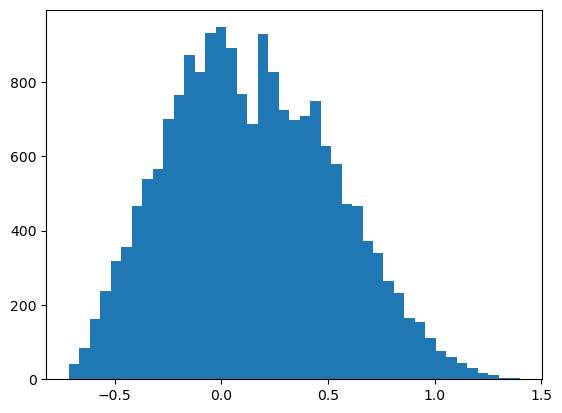

In [8]:
inhib_data = background_saccades[((background_saccades.flash_shown == 1) | (background_saccades.jump_shown == 1))]
inhib_data.loc[inhib_data.relative_eye_movement_time < -1, 'relative_eye_movement_time'] = np.nan
plt.hist(inhib_data.relative_eye_movement_time, 
         bins = len(np.arange(min(inhib_data.relative_eye_movement_time),
                              max(inhib_data.relative_eye_movement_time), 
                              0.05)));

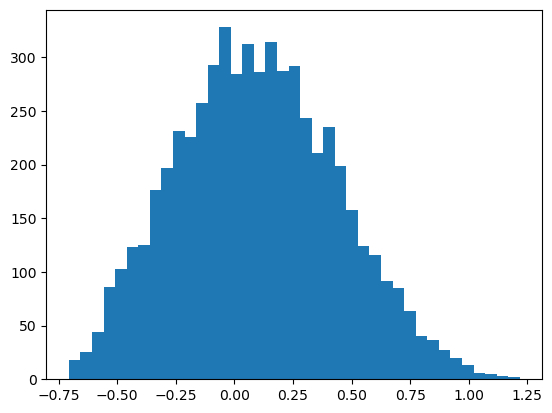

In [9]:
non_inhib_data = background_saccades[((background_saccades.flash_shown == 0) & (background_saccades.jump_shown == 0))]
plt.hist(non_inhib_data.relative_eye_movement_time, 
         bins = len(np.arange(min(non_inhib_data.relative_eye_movement_time),
                              max(non_inhib_data.relative_eye_movement_time), 
                              0.05)));